# Investigación para desarrollo de un sistema de recomendación basado en conocimiento

En este cuaderno se detalla el proceso para desarrollar un sistema de recomendación de espacioes culturales basado en conocimiento (*Knowledged-based Recommender*). Un sistema de recomendación basado en conocimiento opera en función del conocimiento explícito de los atributos del producto, o de las preferencias del usuario, ya sea que se cuente con información relativa al objeto que se desea recomendar, o que el usuario brinde los datos relativos a sus gustos y preferencias (cita). Para este estudio, se emplean dos "entradas" de información: a) por una parte, con las descripciones de espacios culturales disponibles como datos abiertos en el Sistema de Información Cultural (SIC: https://sic.cultura.gob.mx/), datos textuales en los que se implementará la técnica de modelado de tópicos, mediante la que se extraen relaciones semánticas -o tópicos- subyacentes a colecciones de textos -o documentos- y se agrupan según la distribución léxica y la frecuencia gramatical (cita); b) por otra parte, se reunirá información textual relativa a los perfiles de jugadores, según la tipología de Andrzej Marczewski (cita), que comprende al socializador, los espíritus libres, los filántropos, los jugadores, y los disruptores. Con estos datos, se intentará establecer asociaciones entre los tópicos obtenidos de los espacios culturales, y los perfiles de los jugadores, para que el sistema de recomendación brinde al usuario sugerencias personalizadas en función de su tipo de jugador. No obstante, existe la posibilidad de que las relaciones entre estos datos no sean consistentes o sean muy débiles; ante ese panorama, se ensayará la alternativa de planificar mecánicas y dinámicas de gamificación conforme a lo que los tópicos sugieran. 

## Problema
¿Cómo promover la oferta cultural local, regional y nacional e incentivar la demanda cultural de manera más eficiente y escalable?

## Hipótesis
La implementación de un sistema de recomendación dedicado a espacios culturales incrementará la visibilidad de los espacios culturales locales, regionales, y nacionales, y aumentará la afluencia de visitantes.

## Objetivos
* Extraer información relevante sobre espacios culturales de México, o, en su defecto, procesar y "aumentar" la información textual recabada para conformar un corpus lo suficientemente diversificado
* Emplear el modelado de tópicos para obtener las temáticas implícitas o latentes en las colecciones de documentos analizados, para así "entrenar" un modelo de tópicos con el que se pueda realizar inferencias o predicciones con datos textuales nuevos.
* Diseñar un sistema de recomendación basado en conocimiento, que brinde al usuario sugerencias de espacios culturales, en función de los atributos de los primeros, y del perfil del último.

## Fases
Este proyecto se desarrolla en tres fases. La primera comprende la recolección de datos mediante minado web, esto es, la extracción automatizada de informaciónde páginas web; en esta misma etapa, se procesan los datos textuales obtenidos, preparándolos para el modelado de tópicos. Así mismo, y con el propósito de contar con un corpus diversificado, se empleará el aumento de datos, que es la aplicación de operaciones de transformación y de incremento a los datos originales con los que se cuenta al principio del estudio. Durante la segunda fase, se emplea el modelado de tópicos para extraer y agrupar los temas que subyacen a los textos que conforman el corpus de análisis; con base en los tópicos obtenidos, se diseñará el sistema de recomendación de espacios culturales, que operará también con base en la información que el usuario facilite sobre sus propios gustos y preferencias, asociando todo esto -si es factible- con los perfiles de jugadores propuestos por Marczewski. En la última fase de este proyecto, se diseñará una aplicación móvil lúdica o gamificada, que presente al usuario itinerarios de retos y misiones por cumplir, conforme a las sugerencias de espacios culturales que el sistema de recomendaciones devuelva. 

In [1]:
# Primera fase: recolección y procesamiento de datos
# Importación de librerías
import os
import re
import time
from copy import copy
import random
import numpy as np
import pandas as pd
import seaborn as sns
import requests as rq
import dataframe_image as dfi
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline
# Importación de librerías
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.common.exceptions import TimeoutException
from selenium.common.exceptions import UnexpectedAlertPresentException
from selenium.common.exceptions import NoSuchElementException

# Desactivación de advertencias
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action= 'ignore', category= FutureWarning)
warnings.simplefilter(action= 'ignore', category= DeprecationWarning)

In [3]:
# Peticiones a las páginas y conversión a diccionarios de datos
url_teatros = 'https://sic.cultura.gob.mx/opendata/d/0_teatro_directorio.json'
respuesta_teatros = rq.get(url= url_teatros)
datos_teatros = respuesta_teatros.json()
print('La cantidad de teatros registrados en el SIC es de', len(datos_teatros))
url_museos = 'https://sic.cultura.gob.mx/opendata/d/0_museo_directorio.json'
respuesta_museos = rq.get(url= url_museos)
datos_museos = respuesta_museos.json()
print('La cantidad de museos registrados en el SIC es de', len(datos_museos))
url_casas_artesanias = 'https://sic.cultura.gob.mx/opendata/d/0_casa_artesania_directorio.json'
respuesta_casas_artesanias = rq.get(url= url_casas_artesanias)
datos_casas_artesanias = respuesta_casas_artesanias.json()
print('La cantidad de casas de artesanías registradas en el SIC es de', len(datos_casas_artesanias))
url_galerias = 'https://sic.cultura.gob.mx/opendata/d/0_galeria_directorio.json'
respuesta_galerias = rq.get(url= url_galerias)
datos_galerias = respuesta_galerias.json()
print('La cantidad de galerías registradas en el SIC es de', len(datos_galerias))
url_casas_centros_culturales = 'https://sic.cultura.gob.mx/opendata/d/0_centro_cultural_directorio.json'
respuesta_casas_centros_culturales = rq.get(url= url_casas_centros_culturales)
datos_casas_centros_culturales = respuesta_casas_centros_culturales.json()
print('La cantidad de casas y centros culturales registrados en el SIC es de', len(datos_casas_centros_culturales))
url_fototecas = 'https://sic.cultura.gob.mx/opendata/d/0_fototeca_directorio.json'
respuesta_fototecas = rq.get(url= url_fototecas)
datos_fototecas = respuesta_fototecas.json()
print('La cantidad de fototecas registradas en el SIC es de', len(datos_fototecas))
url_fonotecas = 'https://sic.cultura.gob.mx/opendata/d/0_fonoteca_directorio.json'
respuesta_fonotecas = rq.get(url= url_fonotecas)
datos_fonotecas = respuesta_fonotecas.json()
print('La cantidad de fonotecas registradas en el SIC es de', len(datos_fonotecas))
url_catedrales = 'https://sic.cultura.gob.mx/opendata/d/0_catedral_directorio.json'
respuesta_catedrales = rq.get(url= url_catedrales)
datos_catedrales = respuesta_catedrales.json()
print('La cantidad de catedrales registradas en el SIC es de', len(datos_catedrales))
url_patrimonio_humanidad = 'https://sic.cultura.gob.mx/opendata/d/0_patrimonio_humanidad_directorio.json'
respuesta_patrimonio_humanidad = rq.get(url= url_patrimonio_humanidad)
datos_patrimonio_humanidad = respuesta_patrimonio_humanidad.json()
print('La cantidad de patrimonio de la humanidad registrados en el SIC es de', len(datos_patrimonio_humanidad))
url_zonas_arqueologicas = 'https://sic.cultura.gob.mx/opendata/d/0_zona_arqueologica_directorio.json'
respuesta_zonas_arqueologicas = rq.get(url= url_zonas_arqueologicas)
datos_zonas_arqueologicas = respuesta_zonas_arqueologicas.json()
print('La cantidad de zonas arqueológicas registradas en el SIC es de', len(datos_zonas_arqueologicas))

La cantidad de teatros registrados en el SIC es de 723
La cantidad de museos registrados en el SIC es de 1444
La cantidad de casas de artesanías registradas en el SIC es de 179
La cantidad de galerías registradas en el SIC es de 928
La cantidad de casas y centros culturales registrados en el SIC es de 2070
La cantidad de fototecas registradas en el SIC es de 102
La cantidad de fonotecas registradas en el SIC es de 23
La cantidad de catedrales registradas en el SIC es de 81
La cantidad de patrimonio de la humanidad registrados en el SIC es de 36
La cantidad de zonas arqueológicas registradas en el SIC es de 194


In [6]:
# Creación y comprobación de dataframes
df_teatros = pd.DataFrame(data= datos_teatros)
print(df_teatros.columns)
df_teatros.to_csv('DatosSIC/V1/df_teatros_v1.csv')
df_museos = pd.DataFrame(data= datos_museos)
print(df_museos.columns)
df_museos.to_csv('DatosSIC/V1/df_museos_v1.csv')
df_casas_artesanias = pd.DataFrame(data= datos_casas_artesanias)
print(df_casas_artesanias.columns)
df_casas_artesanias.to_csv('DatosSIC/V1/df_casas_artesanias_v1.csv')
df_casas_centros_culturales = pd.DataFrame(data= datos_casas_centros_culturales)
print(df_casas_centros_culturales.columns)
df_casas_centros_culturales.to_csv('DatosSIC/V1/df_casas_centros_culturales_v1.csv')
df_galerias = pd.DataFrame(data= datos_galerias)
print(df_galerias.columns)
df_galerias.to_csv('DatosSIC/V1/df_galerias_v1.csv')
df_fototecas = pd.DataFrame(data= datos_fototecas)
print(df_fototecas.columns)
df_fototecas.to_csv('DatosSIC/V1/df_fototecas_v1.csv')
df_fonotecas = pd.DataFrame(data= datos_fonotecas)
print(df_fonotecas.columns)
df_fonotecas.to_csv('DatosSIC/V1/df_fonotecas_v1.csv')
df_catedrales = pd.DataFrame(data= datos_catedrales)
print(df_catedrales.columns)
df_catedrales.to_csv('DatosSIC/V1/df_catedrales_v1.csv')
df_patrimonio_humanidad = pd.DataFrame(data= datos_patrimonio_humanidad)
print(df_patrimonio_humanidad.columns)
df_patrimonio_humanidad.to_csv('DatosSIC/V1/df_patrimonio_humanidad_v1.csv')
df_zonas_arqueologicas = pd.DataFrame(data= datos_zonas_arqueologicas)
print(df_zonas_arqueologicas.columns)
df_zonas_arqueologicas.to_csv('DatosSIC/V1/df_zonas_arqueologicas_v2.csv')

Index(['teatro_id', 'teatro_nombre', 'teatro_fecha_fundacion',
       'teatro_adscripcion', 'teatro_calle_numero', 'teatro_colonia',
       'teatro_cp', 'teatro_telefono1', 'pagina_web', 'email', 'gmaps_latitud',
       'gmaps_longitud', 'estado_id', 'municipio_id', 'localidad_id',
       'nom_ent', 'nom_mun', 'nom_loc', 'link_sic', 'fecha_mod'],
      dtype='object')
Index(['museo_id', 'museo_tematica_n1', 'museo_nombre',
       'museo_fecha_fundacion', 'museo_adscripcion', 'museo_tipo_de_propiedad',
       'museo_calle_numero', 'museo_colonia', 'museo_cp', 'museo_telefono1',
       'pagina_web', 'pagina_web2', 'email', 'twitter', 'gmaps_latitud',
       'gmaps_longitud', 'estado_id', 'municipio_id', 'localidad_id',
       'nom_ent', 'nom_mun', 'nom_loc', 'link_sic', 'fecha_mod'],
      dtype='object')
Index(['casa_artesania_id', 'casa_artesania_nombre',
       'casa_artesania_fecha_fundacion', 'casa_artesania_adscripcion',
       'casa_artesania_calle_numero', 'casa_artesania_colonia

In [7]:
# Creación de función para remoción de columnas innecesarias
def preparacion(df):
    df.drop(columns= [i for i in df.columns if i in ['gmaps_latitud', 'gmaps_longitud', 'nom_loc',
                                                   'fecha_mod', 'pagina_web2', 'twitter'] or i.endswith(('_id', '_fecha_fundacion',
                                                                                '_calle_numero', '_colonia', '_cp', '_telefono1', 
                                                                               '_telefono2', '_adscripcion', '_tematica_n1',
                                                                              'humanidad_ano_inscripcion', '_tipo_de_propiedad'))], inplace= True)
    nuevos_nombres_columnas = ['Nombre', 'Página Web', 'Email', 'Entidad', 'Municipio', 'Enlace SIC']
    df.columns = [ i for i in nuevos_nombres_columnas]
    return df

In [8]:
# Aplicación de función a todos los marcos de datos
df_casas_artesanias = preparacion(df= df_casas_artesanias)
df_casas_artesanias.to_csv('DatosSIC/v2/df_casas_artesanias_v2.csv')
df_casas_centros_culturales = preparacion(df= df_casas_centros_culturales)
df_casas_centros_culturales.to_csv('DatosSIC/v2/df_casas_centros_culturales_v2.csv')
df_catedrales = preparacion(df= df_catedrales)
df_catedrales.to_csv('DatosSIC/v2/df_catedrales_v2.csv')
df_fonotecas = preparacion(df= df_fonotecas)
df_fonotecas.to_csv('DatosSIC/v2/df_fonotecas_v2.csv')
df_fototecas = preparacion(df= df_fototecas)
df_fototecas.to_csv('DatosSIC/v2/df_fototecas_v2.csv')
df_galerias = preparacion(df= df_galerias)
df_galerias.to_csv('DatosSIC/v2/df_galerias_v2.csv')
df_museos = preparacion(df= df_museos)
df_museos.to_csv('DatosSIC/v2/df_museos_v2.csv')
df_patrimonio_humanidad = preparacion(df= df_patrimonio_humanidad)
df_patrimonio_humanidad.to_csv('DatosSIC/v2/df_patrimonio_humanidad_v2.csv')
df_teatros = preparacion(df= df_teatros)
df_teatros.to_csv('DatosSIC/V2/df_teatros_v2.csv')
df_zonas_arqueologicas = preparacion(df= df_zonas_arqueologicas)
df_zonas_arqueologicas.to_csv('DatosSIC/v2/df_zonas_arqueologicas_v2.csv')

In [36]:
# Creación de función para la obtención de descripciones mediante enlace SIC
def recoleccion_descripciones(ruta_df):
    lista_descripciones = []
    navegador = webdriver.Chrome()
    df = pd.read_csv(ruta_df, index_col= 0)
    for enlace in df['Enlace SIC']:
        try:
            time.sleep(3)
            navegador.execute_script(f"location.href='{enlace}';")
            time.sleep(3)
            navegador.find_element_by_class_name('item_ficha.dos-columnas')
            lista_descripciones.append(navegador.find_element_by_class_name('item_ficha.dos-columnas').text)
            time.sleep(3)
        except NoSuchElementException:
            time.sleep(3)
            lista_descripciones.append(np.NaN)
        except TimeoutException:
            time.sleep(3)
            navegador.refresh()
            try:
                time.sleep(3)
                navegador.find_element_by_class_name('item_ficha.dos-columnas')
                lista_descripciones.append(navegador.find_element_by_class_name('item_ficha.dos-columnas').text)
            except NoSuchElementException:
                time.sleep(3)
                lista_descripciones.append(np.NaN)
        except UnexpectedAlertPresentException:
            time.sleep(3)
            navegador.refresh()
            try:
                time.sleep(3)
                navegador.find_element_by_class_name('item_ficha.dos-columnas')
                lista_descripciones.append(navegador.find_element_by_class_name('item_ficha.dos-columnas').text)
            except NoSuchElementException:
                time.sleep(3)
                lista_descripciones.append(np.NaN)
    df['Descripción'] = lista_descripciones
    df.to_csv(ruta_df)
    navegador.close()
    return df

In [12]:
# Aplicación de función para obtener de manera automatizada las descripciones de los espacios culturales en el SIC
recoleccion_descripciones(ruta_df= 'DatosSIC/V2/df_casas_artesanias_v2.csv')
recoleccion_descripciones(ruta_df= 'DatosSIC/V2/df_casas_centros_culturales_v2.csv')
recoleccion_descripciones(ruta_df= 'DatosSIC/V2/df_catedrales_v2.csv')
recoleccion_descripciones(ruta_df= 'DatosSIC/V2/df_fonotecas_v2.csv')
recoleccion_descripciones(ruta_df= 'DatosSIC/V2/df_fototecas_v2.csv')
recoleccion_descripciones(ruta_df= 'DatosSIC/V2/df_galerias_v2.csv')
recoleccion_descripciones(ruta_df= 'DatosSIC/V2/df_museos_v2.csv')
recoleccion_descripciones(ruta_df= 'DatosSIC/V2/df_patrimonio_humanidad_v2.csv')
recoleccion_descripciones(ruta_df= 'DatosSIC/V2/df_teatros_v2.csv')
recoleccion_descripciones(ruta_df= 'DatosSIC/V2/df_zonas_arqueologicas_v2.csv')

,Unnamed: 0,Nombre,Página Web,Email,Entidad,Municipio,Enlace SIC,Descripción
0,0,El Vallecito,http://www.inah.gob.mx/zonas/58-zona-arqueolog...,direccion.bc@inah.gob.mx,Baja California,Tecate,http://sic.gob.mx/ficha.php?table=zona_arqueol...,Baja California es una región que como el rest...
1,1,Cueva La Música,http://www.inah.gob.mx/es/zonas/59-zona-arqueo...,sierrasanfrancisco@hotmail.com,Baja California Sur,Mulegé,http://sic.gob.mx/ficha.php?table=zona_arqueol...,Se localiza hacia la parte central de la Penín...
2,2,Cueva La Pintada,http://www.inah.gob.mx/es/zonas/59-zona-arqueo...,sierrasanfrancisco@hotmail.com,Baja California Sur,Mulegé,http://sic.gob.mx/ficha.php?table=zona_arqueol...,Se localiza hacia la parte central de la Penín...
3,3,Cueva Las Flechas,http://www.inah.gob.mx/es/zonas/59-zona-arqueo...,sierrasanfrancisco@hotmail.com,Baja California Sur,Mulegé,http://sic.gob.mx/ficha.php?table=zona_arqueol...,Se localiza hacia la parte central de la Penín...
4,4,Cueva Cuesta Palmarito,http://www.inah.gob.mx/es/zonas/59-zona-arqueo...,sierrasanfrancisco@hotmail.com,Baja California Sur,Mulegé,http://sic.gob.mx/ficha.php?table=zona_arqueol...,Se localiza hacia la parte central de la Penín...
...,...,...,...,...,...,...,...,...
189,189,Aké,http://www.inah.gob.mx/es/zonas/20-zona-arqueo...,direccion.yuc@inah.gob.mx,Yucatán,Tixkokob,http://sic.gob.mx/ficha.php?table=zona_arqueol...,La ocupación en Aké se inició desde el Preclás...
190,190,Alta Vista o Chalchihuites,http://www.inah.gob.mx/es/zonas/111-zona-arque...,NaN,Zacatecas,Chalchihuites,http://sic.gob.mx/ficha.php?table=zona_arqueol...,"El nombre de esta zona arqueológica, proviene ..."
191,191,Cerro de las Ventanas,http://inah.gob.mx/zonas/49-zona-arqueologica-...,augusto_torres@inah.gob.mx,Zacatecas,Juchipila,http://sic.gob.mx/ficha.php?table=zona_arqueol...,La Zona Arqueológica Las Ventanas debe su nomb...
192,192,Cerro del Teúl,http://www.inah.gob.mx,laura_solar@inah.gob.mx,Zacatecas,Teúl de González Ortega,http://sic.gob.mx/ficha.php?table=zona_arqueol...,"Se sitúa en el cerro del Teúl, considerada una..."


In [13]:
# Importación de librerías para procesamiento de lenguaje natural
from nltk.corpus import stopwords
from spacy import displacy
import string
import spacy
import json
import re

In [14]:
# Carga de modelo para NLP
nlp_es = spacy.load('es_core_news_lg')

In [19]:
# Preparación de lista con palabras "parada"
palabras_parada = stopwords.words('spanish')
for i in nlp_es.Defaults.stop_words:
    palabras_parada.append(i)
print('Cantidad de palabras "parada" registradas:', len(palabras_parada))

Cantidad de palabras "parada" registradas: 864


In [20]:
# Creación de función para remover palabras de tres o menos caracteres
def remover_palabras_breves(texto):
    nuevo_texto = re.sub(r'\b[a-zA-Z]{1}\b', '', texto)
    nuevo_texto = re.sub(r'\b[a-zA-Z]{2}\b', '', nuevo_texto)
    nuevo_texto = re.sub(r'\b[a-zA-Z]{3}\b', '', nuevo_texto)
    nuevo_texto = re.sub(r'\s+', ' ', nuevo_texto)
    return nuevo_texto

In [21]:
# Creación de función para remover las "stopwords"
def remover_palabras_parada(texto):
    return " ".join([palabra for palabra in str(texto).split() if palabra not in palabras_parada])

In [22]:
# Creación de función para remover "emojis" y demás símbolos
def remover_emojis(cadena):
    patron_emoji = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticones
                               u"\U0001F300-\U0001F5FF"  # símbolos y pictogramas
                               u"\U0001F680-\U0001F6FF"  # transporte símbolos de mapas
                               u"\U0001F1E0-\U0001F1FF"  # banderas (iOS)
                               u"\U00002500-\U00002BEF"  # caracteres chinos
                               u"\U00002702-\U000027B0"
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               u"\U0001f926-\U0001f937"
                               u"\U00010000-\U0010ffff"
                               u"\u2640-\u2642"
                               u"\u2600-\u2B55"
                               u"\u200d"
                               u"\u23cf"
                               u"\u23e9"
                               u"\u231a"
                               u"\ufe0f"  # dingbats (¿?)
                               u"\u3030"
                               "]+", flags= re.UNICODE)
    return patron_emoji.sub(r'', cadena)

In [319]:
# Creación de diccionario organizado por estados, con listas de los municipios, para exclusión en los datos
diccionario_estados_municipios = {
    'Aguascalientes': ['Aguascalientes', 'Asientos', 'Calvillo', 'Cosío', 'El Llano', 'Jesús María', 'Pabellón de Arteaga', 'Rincón de Romos',
                       'San Francisco de los Romo', 'San José de Gracia'],
    'Baja California': ['Ensenada', 'Mexicali', 'Playas de Rosarito', 'Tecate', 'Tijuana'],
    'Baja California Sur': ['Comondú', 'La Paz', 'Loreto', 'Los Cabos', 'Mulegé'],
    'Campeche': ['Calakmul', 'Calkiní', 'Campeche', 'Candelaria', 'Carmen', 'Champotón', 'Escárcega', 'Hecelchakán', 'Hopelchén', 'Palizada', 'Tenabo'],
    'Chiapas': ['Acala', 'Acapetahua', 'Arriaga', 'Berriozábal', 'Bochil', 'Cacahoatán', 'Catazajá', 'Chalchihuitán', 'Chamula', 'Chanal', 
                'Chapultenango', 'Chenalhó', 'Chiapa de Corzo', 'Chilón', 'Cintalapa', 'Coapilla', 'Comitán de Domínguez', 'Copainalá', 'Escuintla', 
                'Frontera Comalapa', 'Frontera Hidalgo', 'Huehuetán', 'Huixtla', 'Huixtán', 'Ixhuatán', 'Ixtacomitán', 'Ixtapa', 'Jiquipilas', 'Juárez', 
                'La Independencia', 'La Libertad', 'La Trinitaria', 'Las Margaritas', 'Las Rosas', 'Mapastepec', 'Mazatán', 'Motozintla', 'Nicolás Ruíz',
                'Ocosingo', 'Ocotepec', 'Ocozocoautla de Espinosa', 'Oxchuc', 'Palenque', 'Pantelhó', 'Pichucalco', 'Pijijiapan', 'Reforma', 'Sabanilla',
                'Salto de Agua', 'San Cristóbal de las Casas', 'San Juan Cancuc', 'Simojovel', 'Sitalá', 'Socoltenango', 'Solosuchiapa', 'Soyaló', 
                'Tapachula', 'Tapalapa', 'Tapilula', 'Tecpatán', 'Tenejapa', 'Teopisca', 'Tonalá', 'Totolapa', 'Tumbalá', 'Tuxtla Chico', 
                'Tuxtla Gutiérrez', 'Tzimol', 'Unión Juárez', 'Venustiano Carranza', 'Villa Comaltitlán',  'Villa Corzo', 'Villaflores', 'Yajalón', 
                'Zinacantán'],
    'Chihuahua': ['Ahumada', 'Aldama', 'Aquiles Serdán', 'Bocoyna', 'Camargo', 'Casas Grandes', 'Chihuahua', 'Coyame del Sotol', 'Cuauhtémoc',
                'Cusihuiriachi', 'Delicias', 'Galeana', 'Guachochi', 'Guerrero', 'Hidalgo del Parral', 'Janos', 'Julimes', 'Juárez', 'La Cruz', 
                  'Madera', 'Meoqui', 'Nuevo Casas Grandes', 'Ojinaga', 'Riva Palacio', 'Rosales', 'Santa Bárbara', 'Satevó', 'Saucillo'],
    'Ciudad de México': ['Azcapotzalco', 'Benito Juárez', 'Coyoacán', 'Cuajimalpa de Morelos', 'Cuauhtémoc', 'Gustavo A. Madero', 'Iztacalco',
                         'Iztapalapa', 'La Magdalena Contreras', 'Miguel Hidalgo', 'Milpa Alta', 'Tlalpan', 'Tláhuac', 'Venustiano Carranza',
                         'Xochimilco', 'Álvaro Obregón'],
    'Coahuila de Zaragoza': ['Acuña', 'Arteaga', 'Cuatro Ciénegas', 'Francisco I. Madero', 'General Cepeda', 'Guerrero', 'Juárez', 'Matamoros',
                             'Monclova', 'Múzquiz', 'Nadadores', 'Ocampo', 'Parras', 'Piedras Negras', 'Ramos Arizpe', 'Sabinas', 'Saltillo',
                             'San Buenaventura', 'San Pedro', 'Torreón', 'Viesca', 'Villa Unión', 'Zaragoza'],
    'Colima': ['Armería', 'Colima', 'Comala', 'Coquimatlán', 'Cuauhtémoc', 'Ixtlahuacán', 'Manzanillo', 'Minatitlán', 'Tecomán', 'Villa de Álvarez'],
    'Distrito Federal': ['Benito Juárez', 'Cuauhtémoc', 'Iztapalapa', 'Tlalpan'],
    'Durango': ['Canatlán', 'Cuencamé', 'Durango', 'General Simón Bolívar', 'Gómez Palacio', 'Lerdo', 'Mapimí', 'Nombre de Dios', 'Nuevo Ideal',
                'Ocampo', 'Peñón Blanco', 'Poanas', 'San Juan de Guadalupe', 'San Juan del Río', 'Santiago Papasquiaro', 'Tlahualilo',
                'Vicente Guerrero'],
    'Guanajuato': ['Abasolo', 'Acámbaro', 'Apaseo el Alto', 'Apaseo el Grande', 'Atarjea', 'Celaya', 'Comonfort', 'Coroneo', 'Cortazar', 'Cuerámaro',
                'Doctor Mora', 'Dolores Hidalgo Cuna de la Independencia Nacional', 'Guanajuato', 'Huanímaro', 'Irapuato', 'Jaral del Progreso', 
                   'Jerécuaro', 'León', 'Manuel Doblado', 'Moroleón', 'Ocampo', 'Pueblo Nuevo', 'Purísima del Rincón', 'Pénjamo', 'Romita', 'Salamanca',
                   'Salvatierra', 'San Diego de la Unión', 'San Felipe', 'San Francisco del Rincón', 'San José Iturbide', 'San Luis de la Paz', 
                   'San Miguel de Allende', 'Santa Catarina', 'Santa Cruz de Juventino Rosas', 'Santiago Maravatío', 'Silao de la Victoria', 
                   'Tarandacuao', 'Tarimoro', 'Tierra Blanca', 'Uriangato', 'Valle de Santiago', 'Victoria', 'Villagrán', 'Xichú', 'Yuriria'],
    'Guerrero': ['Acapulco de Juárez', 'Ayutla de los Libres', 'Azoyú', 'Benito Juárez', 'Chilapa de Álvarez', 'Chilpancingo de los Bravo', 'Copalillo',
                 'Cuajinicuilapa', 'Eduardo Neri', 'Huamuxtitlán', 'Huitzuco de los Figueroa', 'Iguala de la Independencia', 'Ixcateopan de Cuauhtémoc',
                 'Marquelia', 'Ometepec', 'Petatlán', 'Pungarabato', 'Taxco de Alarcón', 'Tecoanapa', 'Teloloapan', 'Tixtla de Guerrero',
                 'Tlapa de Comonfort', 'Zihuatanejo de Azueta', 'Zitlala'],
    'Hidalgo': ['Acaxochitlán', 'Actopan', 'Ajacuba', 'Almoloya', 'Atotonilco el Grande', 'Chilcuautla', 'Epazoyucan', 'Francisco I. Madero',
                'Huejutla de Reyes', 'Huichapan', 'Ixmiquilpan', 'Jacala de Ledezma', 'Mineral de la Reforma', 'Mineral del Monte',
                'Nopala de Villagrán', 'Pachuca de Soto', 'Santiago Tulantepec de Lugo Guerrero', 'Santiago de Anaya', 'Tecozautla', 'Tepeapulco',
                'Tepeji del Río de Ocampo', 'Tizayuca', 'Tlahuelilpan', 'Tolcayuca', 'Tula de Allende', 'Tulancingo de Bravo', 'Villa de Tezontepec',
                'Yahualica', 'Zacualtipán de Ángeles', 'Zempoala', 'Zimapán'],
    'Jalisco': ['Acatic', 'Ahualulco de Mercado', 'Amacueca', 'Amatitán', 'Ameca', 'Arandas',  'Atengo', 'Atenguillo', 'Autlán de Navarro',
                'Cabo Corrientes', 'Casimiro Castillo', 'Chapala', 'Chimaltitán', 'Cocula', 'Colotlán', 'Concepción de Buenos Aires',
                'Cuautitlán de García Barragán', 'Cuautla', 'Degollado', 'Ejutla', 'El Arenal', 'El Grullo', 'El Limón', 'El Salto',
                'Encarnación de Díaz', 'Etzatlán', 'Guachinango', 'Guadalajara', 'Huejuquilla el Alto', 'Jalostotitlán', 'Jesús María', 'La Barca',
                'La Huerta', 'Lagos de Moreno', 'Magdalena', 'Mascota', 'Mezquitic', 'Ocotlán', 'Ojuelos de Jalisco', 'Pihuamo', 'Poncitlán',
                'Puerto Vallarta', 'San Ignacio Cerro Gordo', 'San Juan de los Lagos', 'San Julián', 'San Marcos', 'San Martín Hidalgo',
                'San Martín de Bolaños', 'San Miguel el Alto', 'San Pedro Tlaquepaque', 'San Sebastián del Oeste', 'Sayula', 'Tala', 'Talpa de Allende',
                'Tamazula de Gordiano', 'Tapalpa', 'Tecalitlán', 'Techaluta de Montenegro', 'Tenamaxtlán', 'Teocaltiche', 'Teocuitatlán de Corona',
                'Tepatitlán de Morelos', 'Tequila', 'Teuchitlán', 'Tlajomulco de Zúñiga', 'Tolimán', 'Tomatlán', 'Tonalá', 'Totatiche', 'Tuxcacuesco',
                'Tuxpan', 'Valle de Guadalupe', 'Villa Hidalgo', 'Villa Purificación', 'Zacoalco de Torres', 'Zapopan', 'Zapotiltic',
                'Zapotitlán de Vadillo', 'Zapotlanejo', 'Zapotlán del Rey', 'Zapotlán el Grande'],
    'Michoacán de Ocampo': ['Acuitzio', 'Angangueo', 'Apatzingán', 'Ario', 'Carácuaro', 'Charo', 'Coahuayana', 'Cotija', 'Cuitzeo', 'Hidalgo',
                            'Huandacareo', 'Jiquilpan', 'La Piedad', 'Lázaro Cárdenas', 'Maravatío', 'Morelia', 'Nahuatzen', 'Pátzcuaro', 'Quiroga',
                            'Salvador Escalante', 'Senguio', 'Tacámbaro', 'Tangancícuaro', 'Tepalcatepec', 'Tingambato', 'Tingüindín', 'Tlalpujahua',
                            'Tlazazalca', 'Tuxpan', 'Tuzantla', 'Tzintzuntzan', 'Uruapan', 'Venustiano Carranza', 'Vista Hermosa', 'Yurécuaro', 'Zamora',
                            'Zinapécuaro', 'Zitácuaro'],
    'Morelos': ['Atlatlahucan', 'Axochiapan', 'Ayala', 'Cuautla', 'Cuernavaca', 'Jantetelco', 'Jojutla', 'Jonacatepec', 'Jonacatepec de Leandro Valle',
                'Miacatlán', 'Ocuituco', 'Temixco', 'Tepoztlán', 'Tlaltizapán de Zapata', 'Tlaquiltenango', 'Tlayacapan', 'Xochitepec', 'Yautepec',
                'Yecapixtla', 'Zacatepec'],
    'México': ['Acambay', 'Acambay de Ruíz Castañeda', 'Acolman', 'Almoloya de Alquisiras', 'Amecameca', 'Apaxco', 'Atizapán de Zaragoza',
               'Atlacomulco', 'Chalco', 'Chimalhuacán', 'Cuautitlán', 'Cuautitlán Izcalli', 'Ecatepec de Morelos', 'El Oro', 'Huixquilucan', 
               'Isidro Fabela', 'Ixtapaluca', 'Ixtlahuaca', 'Juchitepec', 'La Paz', 'Lerma', 'Malinalco', 'Metepec', 'Naucalpan de Juárez', 'Nextlalpan',
               'Nezahualcóyotl', 'Nicolás Romero', 'Ocoyoacac', 'Ocuilan', 'Otumba', 'Otzoloapan', 'San Martín de las Pirámides', 'San Mateo Atenco',
               'Sultepec', 'Tecámac', 'Tejupilco', 'Tenango del Aire', 'Tenango del Valle', 'Teotihuacán', 'Tepetlaoxtoc', 'Tepetlixpa', 'Tepotzotlán',
               'Texcoco', 'Tlalmanalco', 'Tlalnepantla de Baz', 'Toluca', 'Tultepec', 'Valle de Bravo', 'Valle de Chalco Solidaridad', 'Villa Guerrero',
               'Zinacantepec', 'Zumpango'],
    'Nayarit': ['Acaponeta', 'Ahuacatlán', 'Bahía de Banderas', 'Compostela', 'Ixtlán del Río', 'Jala', 'Santiago Ixcuintla', 'Tepic'],
    'Nuevo León': ['Abasolo', 'Agualeguas', 'Allende', 'Anáhuac', 'Apodaca', 'Bustamante', 'Cadereyta Jiménez', 'Ciénega de Flores', 'Doctor González',
                   'El Carmen', 'Galeana', 'García', 'General Bravo', 'General Escobedo', 'General Zaragoza', 'General Zuazua', 'Guadalupe', 'Hidalgo',
                   'Higueras', 'Juárez', 'Lampazos de Naranjo', 'Linares', 'Los Herreras', 'Marín', 'Mier y Noriega', 'Mina', 'Montemorelos', 
                   'Monterrey', 'Rayones', 'Sabinas Hidalgo', 'Salinas Victoria', 'San Nicolás de los Garza', 'San Pedro Garza García', 'Santa Catarina',
                   'Santiago', 'Vallecillo', 'Villaldama'],
    'Oaxaca': ['Acatlán de Pérez Figueroa', 'Asunción Nochixtlán', 'Chahuites', 'Ciudad Ixtepec', 'Ciénega de Zimatlán', 'El Espinal', 'Guadalupe Etla',
               'Guelatao de Juárez', 'Heroica Ciudad de Huajuapan de León', 'Heroica Ciudad de Juchitán de Zaragoza', 'Heroica Ciudad de Tlaxiaco',
               'Heroica Villa Tezoatlán de Segura y Luna, Cuna de la Independencia de Oaxaca', 'Huautla de Jiménez', 'Ixtlán de Juárez', 'Loma Bonita',
               'Magdalena Jaltepec', 'Magdalena Tequisistlán', 'Miahuatlán de Porfirio Díaz', 'Natividad', 'Nazareno Etla', 'Oaxaca de Juárez',
               'Ocotlán de Morelos', 'Putla Villa de Guerrero', 'Reforma de Pineda', 'Salina Cruz', 'San Agustín Etla', 'San Bartolo Coyotepec',
               'San Esteban Atatlahuca', 'San Francisco Telixtlahuaca', 'San Jacinto Amilpas', 'San Jerónimo Tlacochahuaya',
               'San Juan Bautista Cuicatlán', 'San Juan Bautista Tuxtepec', 'San Juan Mixtepec', 'San Juan Petlapa', 'San Juan del Estado',
               'San Martín Huamelúlpam', 'San Miguel Tequixtepec', 'San Miguel el Grande', 'San Pablo Etla', 'San Pablo Huitzo', 'San Pablo Huixtepec',
               'San Pablo Villa de Mitla', 'San Pedro Apóstol', 'San Pedro Huilotepec', 'San Pedro Ixtlahuaca', 'San Pedro Juchatengo',
               'San Pedro Mixtepec', 'San Pedro Ocotepec', 'San Pedro Yucunama', 'San Pedro y San Pablo Ayutla', 'San Pedro y San Pablo Teposcolula',
               'San Pedro y San Pablo Tequixtepec', 'San Sebastián Tutla', 'Santa Ana del Valle', 'Santa Catarina Minas', 'Santa Cruz Xitla',
               'Santa Cruz Xoxocotlán', 'Santa Lucía del Camino', 'Santa María Atzompa', 'Santa María Huatulco', 'Santa María Tlahuitoltepec',
               'Santa María Yucuhiti', 'Santiago Chazumba', 'Santiago Huauclilla', 'Santiago Matatlán', 'Santiago Niltepec', 
               'Santiago Pinotepa Nacional', 'Santiago Suchilquitongo', 'Santo Domingo Petapa', 'Santo Domingo Tehuantepec', 'Santos Reyes Tepejillo',
               'Silacayoápam', 'Tamazulápam del Espíritu Santo', 'Teotitlán del Valle', 'Tepelmeme Villa de Morelos', 'Tlacolula de Matamoros',
               'Totontepec Villa de Morelos', 'Villa Talea de Castro', 'Villa de Etla', 'Villa de Zaachila'],
    'Puebla': ['Acatlán', 'Ahuazotepec', 'Ajalpan', 'Albino Zertuche', 'Aljojuca', 'Amozoc', 'Aquixtla', 'Atexcal', 'Atlixco', 'Atoyatempan',
               'Atzitzihuacán', 'Ayotoxco de Guerrero', 'Calpan', 'Camocuautla', 'Chalchicomula de Sesma', 'Chiautla', 'Chietla', 'Chigmecatitlán',
               'Chignahuapan', 'Chignautla', 'Cohuecan', 'Cuautempan', 'Cuautinchán', 'Cuautlancingo', 'Cuetzalan del Progreso', 'Francisco Z. Mena',
               'Huaquechula', 'Huehuetlán el Chico', 'Huejotzingo', 'Huitziltepec', 'Ixcaquixtla', 'Ixtacamaxtitlán', 'Izúcar de Matamoros', 'Nopalucan',
               'Piaxtla', 'Puebla', 'Quecholac', 'San Andrés Cholula', 'San Gabriel Chilac', 'San Martín Texmelucan', 'San Matías Tlalancaleca',
               'San Pedro Cholula', 'San Salvador Huixcolotla', 'Santo Tomás Hueyotlipan', 'Tecali de Herrera', 'Tehuacán', 'Tehuitzingo', 
               'Tepango de Rodríguez', 'Tepatlaxco de Hidalgo', 'Tepeojuma', 'Tepexi de Rodríguez', 'Tepeyahualco', 'Tetela de Ocampo'
               , 'Teteles de Avila Castillo', 'Teziutlán', 'Tlacotepec de Benito Juárez', 'Tlapanalá', 'Tlatlauquitepec', 'Tochimilco', 'Tochtepec',
               'Tuzamapan de Galeana', 'Xicotepec', 'Xiutetelco', 'Xochiapulco', 'Zacapala', 'Zacapoaxtla', 'Zacatlán', 'Zapotitlán', 'Zautla',
               'Zoquiapan'],
    'Querétaro': ['Amealco de Bonfil', 'Arroyo Seco', 'Cadereyta de Montes', 'Colón', 'Corregidora', 'El Marqués', 'Ezequiel Montes', 'Jalpan de Serra',
                  'Landa de Matamoros', 'Pedro Escobedo', 'Pinal de Amoles', 'Querétaro', 'San Joaquín', 'San Juan del Río', 'Tequisquiapan', 'Tolimán'],
    'Quintana Roo': ['Bacalar', 'Benito Juárez', 'Cozumel', 'Felipe Carrillo Puerto', 'Isla Mujeres', 'José María Morelos', 'Lázaro Cárdenas',
                     'Othón P. Blanco', 'Puerto Morelos', 'Solidaridad', 'Tulum'],
    'San Luis Potosí': ['Ahualulco', 'Alaquines', 'Aquismón', 'Catorce', 'Cerritos', 'Charcas', 'Ciudad Fernández', 'Ciudad Valles', 'Ciudad del Maíz',
                        'Ebano', 'Guadalcázar', 'Huehuetlán', 'Matehuala', 'Mexquitic de Carmona', 'Rayón', 'Rioverde', 'Salinas', 'San Ciro de Acosta',
                        'San Luis Potosí', 'San Nicolás Tolentino', 'Santa Catarina', 'Santa María del Río', 'Soledad de Graciano Sánchez', 'Tamasopo',
                        'Tamuín', 'Tancanhuitz', 'Venado', 'Villa de Reyes', 'Xilitla'],
    'Sinaloa': ['Ahome', 'Concordia', 'Cosalá', 'Culiacán', 'El Fuerte', 'Escuinapa', 'Guasave', 'Mazatlán', 'Mocorito', 'Rosario', 'Salvador Alvarado',
                'San Ignacio', 'Sinaloa'],
    'Sonora': ['Alamos', 'Arizpe', 'Bácum', 'Caborca', 'Cajeme', 'Cananea', 'Empalme', 'Etchojoa', 'General Plutarco Elías Calles', 'Guaymas',
               'Hermosillo', 'Huachinera', 'Huatabampo', 'Magdalena', 'Naco', 'Nacozari de García', 'Navojoa', 'Nogales', 'Pitiquito', 'Puerto Peñasco',
               'Rosario', 'San Luis Río Colorado', 'Santa Ana', 'Trincheras', 'Ures'],
    'Tabasco': ['Balancán', 'Centla', 'Centro', 'Comalcalco', 'Cunduacán', 'Emiliano Zapata', 'Huimanguillo', 'Jalapa', 'Jalpa de Méndez', 'Jonuta',
                'Tacotalpa', 'Teapa', 'Tenosique'],
    'Tamaulipas': ['Aldama', 'Altamira', 'Camargo', 'Ciudad Madero', 'El Mante', 'González', 'Jiménez', 'Matamoros', 'Mier', 'Miguel Alemán',
                   'Nuevo Laredo', 'Ocampo', 'Reynosa', 'Soto la Marina', 'Tampico', 'Tula', 'Victoria', 'Xicoténcatl'],
    'Tlaxcala': ['Apizaco', 'Atltzayanca', 'Calpulalpan', 'Chiautempan', 'Huamantla', 'Hueyotlipan', 'Ixtenco', 'Mazatecochco de José María Morelos',
                 'Nanacamilpa de Mariano Arista', 'Natívitas', 'Papalotla de Xicohténcatl', 'San Lorenzo Axocomanitla', 'Santa Cruz Tlaxcala',
                 'Tepeyanco', 'Tlaxcala', 'Tlaxco', 'Totolac', 'Yauhquemehcan', 'Zacatelco'],
    'Veracruz de Ignacio de la Llave': ['Actopan', 'Acula', 'Alto Lucero de Gutiérrez Barrios', 'Alvarado', 'Amatitlán', 'Atoyac', 'Atzalan',
                                        'Boca del Río', 'Camerino Z. Mendoza', 'Castillo de Teayo', 'Chiconamel', 'Chontla', 'Coatepec', 'Coatzacoalcos',
                                        'Coscomatepec', 'Córdoba', 'Emiliano Zapata', 'Fortín', 'Gutiérrez Zamora', 'Huatusco', 'Hueyapan de Ocampo',
                                        'Huiloapan de Cuauhtémoc', 'Ignacio de la Llave', 'Jamapa', 'Jilotepec', 'Jáltipan', 'La Antigua',
                                        'Misantla', 'Orizaba', 'Otatitlán', 'Pajapan', 'Papantla', 'Poza Rica de Hidalgo', 'Pánuco', 'San Andrés Tuxtla',
                                        'Santiago Tuxtla', 'Tecolutla', 'Teocelo', 'Texistepec', 'Tlacotalpan', 'Tuxpan', 'Ursulo Galván',
                                        'Vega de Alatorre', 'Veracruz', 'Xalapa', 'Xico', 'Yanga', 'Zentla', 'Álamo Temapache'],
    'Yucatán': ['Acanceh', 'Akil', 'Cenotillo', 'Conkal', 'Dzemul', 'Dzidzantún', 'Dzoncauich', 'Hoctún', 'Izamal', 'Maxcanú', 'Motul', 'Mérida',
                'Oxkutzcab', 'Río Lagartos', 'Santa Elena', 'Teabo', 'Tecoh', 'Tekax', 'Temozón', 'Tinum', 'Tixkokob', 'Valladolid', 'Yaxcabá'],
    'Zacatecas': ['Atolinga', 'Cañitas de Felipe Pescador', 'Chalchihuites', 'Fresnillo', 'Guadalupe', 'Jalpa', 'Jerez', 'Juan Aldama', 'Juchipila',
                  'Loreto', 'Mazapil', 'Monte Escobedo', 'Nochistlán de Mejía', 'Ojocaliente', 'Pinos', 'Sombrerete', 'Susticacán', 'Tepechitlán',
                  'Teúl de González Ortega', 'Tlaltenango de Sánchez Román', 'Trinidad García de la Cadena', 'Valparaíso', 'Villa García',
                  'Villa Hidalgo', 'Villanueva', 'Zacatecas']
}

In [326]:
for e in diccionario_estados_municipios.keys():
    for m in diccionario_estados_municipios.values():
        for i in m[:1]:
            print(i)

Aguascalientes
Ensenada
Comondú
Calakmul
Acala
Ahumada
Azcapotzalco
Acuña
Armería
Benito Juárez
Canatlán
Abasolo
Acapulco de Juárez
Acaxochitlán
Acatic
Acuitzio
Atlatlahucan
Acambay
Acaponeta
Abasolo
Acatlán de Pérez Figueroa
Acatlán
Amealco de Bonfil
Bacalar
Ahualulco
Ahome
Alamos
Balancán
Aldama
Apizaco
Actopan
Acanceh
Atolinga
Aguascalientes
Ensenada
Comondú
Calakmul
Acala
Ahumada
Azcapotzalco
Acuña
Armería
Benito Juárez
Canatlán
Abasolo
Acapulco de Juárez
Acaxochitlán
Acatic
Acuitzio
Atlatlahucan
Acambay
Acaponeta
Abasolo
Acatlán de Pérez Figueroa
Acatlán
Amealco de Bonfil
Bacalar
Ahualulco
Ahome
Alamos
Balancán
Aldama
Apizaco
Actopan
Acanceh
Atolinga
Aguascalientes
Ensenada
Comondú
Calakmul
Acala
Ahumada
Azcapotzalco
Acuña
Armería
Benito Juárez
Canatlán
Abasolo
Acapulco de Juárez
Acaxochitlán
Acatic
Acuitzio
Atlatlahucan
Acambay
Acaponeta
Abasolo
Acatlán de Pérez Figueroa
Acatlán
Amealco de Bonfil
Bacalar
Ahualulco
Ahome
Alamos
Balancán
Aldama
Apizaco
Actopan
Acanceh
Atolinga
Agua

In [345]:
# Creación de función de carga, de creación de subconjuntos y de preprocesamiento de texto
def preparacion_datos(ruta_df):
    df = pd.read_csv(ruta_df, index_col= 0)
    df_notnans = df[df['Descripción'].notna()]
    df_notnans['Texto limpio'] = df_notnans['Descripción'].apply(lambda x: re.sub(r'http\S+', '', x))
    df_notnans['Texto limpio'] = df_notnans['Texto limpio'].str.replace('\d+', '')
    df_notnans['Texto limpio'] = df_notnans['Texto limpio'].str.replace('\n+', ' ')
    df_notnans['Texto limpio'] = df_notnans['Texto limpio'].apply(lambda x: remover_palabras_parada(x))
    df_notnans['Texto limpio'] = df_notnans['Texto limpio'].apply(lambda x: remover_emojis(x))
    lista_exclusiones = ['enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio', 'julio', 'agosto', 'septiembre',
                   'octubre', 'noviembre', 'diciembre', 'lunes', 'martes', 'miércoles', 'jueves', 'viernes', 'sábado',
                        'domingo', ]
    for e in lista_exclusiones:
        df_notnans['Texto limpio'] = df_notnans['Texto limpio'].str.replace(e, '')
    for e in diccionario_estados_municipios.keys():
        df_notnans['Texto limpio'] = df_notnans['Texto limpio'].str.replace(e, '')
        for m in diccionario_estados_municipios.values():
            for i in m:
                df_notnans['Texto limpio'] = df_notnans['Texto limpio'].str.replace(i, '')
    df_notnans['Texto limpio'] = df_notnans['Texto limpio'].str.lower()
    df_notnans['Texto limpio'] = df_notnans['Texto limpio'].apply(lambda x: remover_palabras_breves(x))
    df_notnans['Texto limpio'] = df_notnans['Texto limpio'].apply(lambda x: re.sub('[%s]' % re.escape(string.punctuation), '' , x))
    df_notnans['Texto limpio'] = df_notnans['Texto limpio'].str.strip()
    df_notnans['Texto limpio'] = df_notnans['Texto limpio'].astype(str)
    df_notnans['Texto limpio'] = df_notnans['Texto limpio'].replace('', np.NaN)
    df_nans = df_notnans[df_notnans['Texto limpio'].isna()]
    df_notnans = df_notnans[df_notnans['Texto limpio'].notna()]
    df_notnans.reset_index(inplace= True)
    df_notnans.drop(columns= ['index', 'Unnamed: 0'], inplace= True)
    df_nans.reset_index(inplace= True)
    df_nans.drop(columns= ['index', 'Unnamed: 0'], inplace= True)
    return df_notnans, df_nans

<>:6: DeprecationWarning: invalid escape sequence \d
<>:6: DeprecationWarning: invalid escape sequence \d
C:\Users\jedua\AppData\Local\Temp\ipykernel_19840\173791959.py:6: DeprecationWarning: invalid escape sequence \d
  df_notnans['Texto limpio'] = df_notnans['Texto limpio'].str.replace('\d+', '')


In [346]:
# Carga de los subconjuntos de datos ya procesados
df_casas_artesanias_entrenamiento, df_casas_artesanias_prueba = preparacion_datos(ruta_df= 'DatosSIC/V2/df_casas_artesanias_v2.csv')
df_casas_centros_culturales_entrenamiento, df_casas_centros_culturales_prueba = preparacion_datos('DatosSIC/V2/df_casas_centros_culturales_v2.csv')
df_catedrales_entrenamiento, df_catedrales_prueba = preparacion_datos(ruta_df= 'DatosSIC/V2/df_catedrales_v2.csv')
df_fonotecas_entrenamiento, df_fonotecas_prueba = preparacion_datos(ruta_df= 'DatosSIC/V2/df_fonotecas_v2.csv')
df_fototecas_entrenamiento, df_fototecas_prueba = preparacion_datos(ruta_df= 'DatosSIC/V2/df_fototecas_v2.csv')
df_galerias_entrenamiento, df_galerias_prueba = preparacion_datos(ruta_df= 'DatosSIC/V2/df_galerias_v2.csv')
df_museos_entrenamiento, df_museos_prueba = preparacion_datos(ruta_df= 'DatosSIC/V2/df_museos_v2.csv')
df_patrimonio_humanidad_entrenamiento, df_patrimonio_humanidad_prueba = preparacion_datos(ruta_df= 'DatosSIC/V2/df_patrimonio_humanidad_v2.csv')
df_teatros_entrenamiento, df_teatros_prueba = preparacion_datos(ruta_df= 'DatosSIC/V2/df_teatros_v2.csv')
df_zonas_arqueologicas_entrenamiento, df_zonas_arqueologicas_prueba = preparacion_datos(ruta_df= 'DatosSIC/V2/df_zonas_arqueologicas_v2.csv')

In [157]:
# Importación de librerías para aumento de datos
import nlpaug.augmenter.char as nac
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.sentence as nas
import nlpaug.flow as nafc
from nlpaug.util import Action

In [163]:
# Construcción de objeto "aumentador"
aumentador = naw.ContextualWordEmbsAug(model_path= 'bert-base-multilingual-uncased', aug_p= 0.4, aug_min= 10, aug_max= 30)

In [347]:
# Creación de marcos generales para aumento de datos
df_01 = df_casas_artesanias_entrenamiento
df_02 = df_casas_centros_culturales_entrenamiento
df_03 = df_catedrales_entrenamiento
df_04 = df_fonotecas_entrenamiento
df_05 = df_fototecas_entrenamiento
df_06 = df_galerias_entrenamiento
df_07 = df_museos_entrenamiento
df_08 = df_patrimonio_humanidad_entrenamiento
df_09 = df_teatros_entrenamiento
df_10 = df_zonas_arqueologicas_entrenamiento
lista_dfs_entrenamiento = [df_01, df_02, df_03, df_04, df_05, df_06, df_07, df_08, df_09, df_10]
df_general_entrenamiento = pd.concat(objs= lista_dfs_entrenamiento, ignore_index= True)
df_11 = df_casas_artesanias_prueba
df_12 = df_casas_centros_culturales_prueba
df_13 = df_catedrales_prueba
df_14 = df_fonotecas_prueba
df_15 = df_fototecas_prueba
df_16 = df_galerias_prueba
df_17 = df_museos_prueba
df_18 = df_patrimonio_humanidad_prueba
df_19 = df_teatros_prueba
df_20 = df_zonas_arqueologicas_prueba
lista_dfs_prueba = [df_11, df_12, df_13, df_14, df_15, df_16, df_17, df_18, df_19, df_20]
df_general_prueba = pd.concat(objs= lista_dfs_prueba, ignore_index= True)

In [348]:
# Comprobación de marco de datos general sin valores nulos (NaN)
df_general_entrenamiento

,Nombre,Página Web,Email,Entidad,Municipio,Enlace SIC,Descripción,Texto limpio
0,Casa de Artesanías del Centro de Artes y Oficios,http://www.aguascalientes.gob.mx,artesyoficios1979@hotmail.com,Aguascalientes,Aguascalientes,http://sic.gob.mx/ficha.php?table=casa_artesan...,"Cursos de cerámica, vitrales, textiles, deshil...",cursos cerámica vitrales textiles deshilados v...
1,Casa de las Artesanías Aguascalientes,https://www.facebook.com/artesaniasags/timeline,casadelasartesaniasaguascalientesnex@gmail.com...,Aguascalientes,Aguascalientes,http://sic.gob.mx/ficha.php?table=casa_artesan...,Horario de sevicio: lunes a domingo de 11 a 23...,horario sevicio
2,Casa del Artesano Sudcaliforniano,http://casadelartesanosudcaliforniano.blogspot...,casartsbcs@gmail.com,Baja California Sur,La Paz,http://sic.gob.mx/ficha.php?table=casa_artesan...,Venta: artesanìas de maderas muertas de cactos...,venta artesanìas maderas muertas cactos concha...
3,Bazar Artesanal,NaN,NaN,Campeche,Campeche,http://sic.gob.mx/ficha.php?table=casa_artesan...,"Venta: Madera, fibra vegetal, barro, vidrio.",venta fibra vegetal barro vidrio
4,Tienda de Artesanías del DIF,NaN,NaN,Colima,Colima,http://sic.gob.mx/ficha.php?table=casa_artesan...,"Venta: Barro (figuras), madera (muebles, másca...",venta barro figuras madera muebles máscaras cu...
...,...,...,...,...,...,...,...,...
4510,Aké,http://www.inah.gob.mx/es/zonas/20-zona-arqueo...,direccion.yuc@inah.gob.mx,Yucatán,Tixkokob,http://sic.gob.mx/ficha.php?table=zona_arqueol...,La ocupación en Aké se inició desde el Preclás...,ocupación aké inició preclásico tardío cont...
4511,Alta Vista o Chalchihuites,http://www.inah.gob.mx/es/zonas/111-zona-arque...,NaN,Zacatecas,Chalchihuites,http://sic.gob.mx/ficha.php?table=zona_arqueol...,"El nombre de esta zona arqueológica, proviene ...",nombre zona arqueológica proviene descubrimien...
4512,Cerro de las Ventanas,http://inah.gob.mx/zonas/49-zona-arqueologica-...,augusto_torres@inah.gob.mx,Zacatecas,Juchipila,http://sic.gob.mx/ficha.php?table=zona_arqueol...,La Zona Arqueológica Las Ventanas debe su nomb...,zona arqueológica ventanas nombre ventanas cas...
4513,Cerro del Teúl,http://www.inah.gob.mx,laura_solar@inah.gob.mx,Zacatecas,Teúl de González Ortega,http://sic.gob.mx/ficha.php?table=zona_arqueol...,"Se sitúa en el cerro del Teúl, considerada una...",sitúa cerro teúl considerada complejas patrón ...


In [349]:
# Comprobación de marco de datos general con valores nulos (NaN)
df_general_prueba

,Nombre,Página Web,Email,Entidad,Municipio,Enlace SIC,Descripción,Texto limpio
0,Centro de Seguridad Social IMSS Aguascalientes,http://www.imss.gob.mx,jose.padillac@imss.gob.mx,Aguascalientes,Aguascalientes,http://sic.gob.mx/ficha.php?table=centro_cultu...,1 de enero de 1964,NaN
1,Centro de Artes Visuales,NaN,centrodeartesvisuales@yahoo.com.mx,Aguascalientes,Aguascalientes,http://sic.gob.mx/ficha.php?table=centro_cultu...,1 de enero de 1975,NaN
2,Casa de la Cultura de Calvillo,http://www.aguascalientes.gob.mx,calvillo.ica@gmail.com; ica@aguascalientes.gob.mx,Aguascalientes,Calvillo,http://sic.gob.mx/ficha.php?table=centro_cultu...,5 de diciembre de 1980,NaN
3,Casa de Cultura de Jesús María,http://www.aguascalientes.gob.mx,jmacultura@hotmail.com; ica@aguascalientes.gob.mx,Aguascalientes,Jesús María,http://sic.gob.mx/ficha.php?table=centro_cultu...,3 de julio de 1983,NaN
4,Casa de la Cultura de Tepezalá,http://www.aguascalientes.gob.mx,tepcultura@hotmail.com; ica@aguascalientes.gob.mx,Aguascalientes,Tepezalá,http://sic.gob.mx/ficha.php?table=centro_cultu...,7 de noviembre de 1998,NaN
...,...,...,...,...,...,...,...,...
888,"Teatro Pedrito, A.C.",NaN,NaN,Yucatán,Mérida,http://sic.gob.mx/ficha.php?table=teatro&table...,20 de julio de 1972,NaN
889,Teatro Fantasio,NaN,NaN,Yucatán,Mérida,http://sic.gob.mx/ficha.php?table=teatro&table...,15 de mayo de 1952,NaN
890,Foro Alternativo Rubén Chacón,NaN,foroalternativoruben.chacon@hotmail.com,Yucatán,Mérida,http://sic.gob.mx/ficha.php?table=teatro&table...,14 de julio de 2012,NaN
891,Teatro Casa Tanicho,http://teatrocasatanicho.com/index.html,casatanicho@gmail.com,Yucatán,Mérida,http://sic.gob.mx/ficha.php?table=teatro&table...,1 de enero de 2013,NaN


In [162]:
# Creación de muestra para generar texto aumentado
lista_textos = df_general_entrenamiento['Descripción'].sample(n= 893).to_list()
lista_textos[:10]

['El inmueble fue adaptado para albergar a Cirkóptero (espacio de creación, entrenamiento y presentación de artes circenses).\n\nArquitecto o institución que lo remodeló: Cruces Intervención de las Artes, A.C.\n\nUsos que ha tenido el inmueble desde su construcción: Cancha de squash, bodega.\n\nPrimera representación:\nTítulo de la obra: Work in progress Elemental.\nDirector: Fernanda Palacios.\nEscenógrafo: Jorge Díaz Mendoza.\nActores:\nFernanda Palacios.\nIvan Pulido.\nEventos realizados (los más recientes):\nTítulo de la obra: Work in Progress Elemental\nFecha: 21 y 22 de Febrero 2020.\nTítulo de la obra: Clase Magistral de Mástil Chino.\nFecha: 8 de Diciembre 2019.\nTítulo de la obra: Taller de creación en aéreos.\nFecha: 5 y 6 de Diciembre 2019.\nTipo de espectáculos que se realizan:\nTeatro, espectáculos infantiles, circo, workshops, working progress, laboratorios creativos, residencias creativas y talleres especializados.',
 'El municipio de Ajalpan tiene una extensión territor

In [164]:
# Creación de lista de textos aumentados
lista_textos_aumentados = []

In [165]:
# Aumento de texto e incorporación en lista
for i in lista_textos:
    lista_textos_aumentados.append(aumentador.augment(i))

In [166]:
# Comprobación de lista de textos aumentados
print(len(lista_textos_aumentados))
lista_textos_aumentados[:10]

893


['el inmueble fue adaptado para albergar a cirkoptero ( espacio de creacion, traduccion y produccion de artes circenses ). nombre o persona que lo remodelo : cruces dias de las artes, a. c. usos que ha tenido el inmueble desde su establecimiento : cancha de squash, bodega. primera temporada : titulo de la obra : work in progress elemental. director : fernanda palacios. escenografo : jorge diaz mendoza. actores : fernanda palacios. ivan pulido. eventos sociales ( los mas recientes ) : titulo de la obra : work in progress elemental fecha : 21 y 22 de febrero 2020. titulo de la obra : clase magistral de mastil chino. fecha : 8 de diciembre 2019. titulo de la obra : taller de creacion en aereos. fecha : 5 y 6 de diciembre 2019. tipo de cursos que se realizan : teatro, exposiciones infantiles, circo, workshops, working progress, eventos creativos, actividades creativas y talleres familiares.',
 'el municipio de ajalpan tiene una extension media de 678. 655° ; colinda al norte con los federa

In [285]:
# Segunda fase: modelado de tópicos
#from bertopic import BERTopic
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
from gensim.models import LdaModel
import gensim.corpora as corpora
from gensim.test.utils import common_texts
from gensim.models import Word2Vec
import pyLDAvis
import pyLDAvis.gensim_models

In [350]:
"""Se asigna el tipo "str" a la columna de "Texto limpio", para asegurar que el modelo procese datos textuales (si procesa otro tipo de texto,
    arrojará error; además, se guarda el marco general."""
df_general_entrenamiento['Texto limpio'] = df_general_entrenamiento['Texto limpio'].astype(str)
df_general_entrenamiento.to_csv('DatosSIC/V3/df_general_entrenamiento.csv')
df_general_entrenamiento = pd.read_csv('DatosSIC/V3/df_general_entrenamiento.csv', index_col= 0)
df_general_entrenamiento

,Nombre,Página Web,Email,Entidad,Municipio,Enlace SIC,Descripción,Texto limpio
0,Casa de Artesanías del Centro de Artes y Oficios,http://www.aguascalientes.gob.mx,artesyoficios1979@hotmail.com,Aguascalientes,Aguascalientes,http://sic.gob.mx/ficha.php?table=casa_artesan...,"Cursos de cerámica, vitrales, textiles, deshil...",cursos cerámica vitrales textiles deshilados v...
1,Casa de las Artesanías Aguascalientes,https://www.facebook.com/artesaniasags/timeline,casadelasartesaniasaguascalientesnex@gmail.com...,Aguascalientes,Aguascalientes,http://sic.gob.mx/ficha.php?table=casa_artesan...,Horario de sevicio: lunes a domingo de 11 a 23...,horario sevicio
2,Casa del Artesano Sudcaliforniano,http://casadelartesanosudcaliforniano.blogspot...,casartsbcs@gmail.com,Baja California Sur,La Paz,http://sic.gob.mx/ficha.php?table=casa_artesan...,Venta: artesanìas de maderas muertas de cactos...,venta artesanìas maderas muertas cactos concha...
3,Bazar Artesanal,NaN,NaN,Campeche,Campeche,http://sic.gob.mx/ficha.php?table=casa_artesan...,"Venta: Madera, fibra vegetal, barro, vidrio.",venta fibra vegetal barro vidrio
4,Tienda de Artesanías del DIF,NaN,NaN,Colima,Colima,http://sic.gob.mx/ficha.php?table=casa_artesan...,"Venta: Barro (figuras), madera (muebles, másca...",venta barro figuras madera muebles máscaras cu...
...,...,...,...,...,...,...,...,...
4510,Aké,http://www.inah.gob.mx/es/zonas/20-zona-arqueo...,direccion.yuc@inah.gob.mx,Yucatán,Tixkokob,http://sic.gob.mx/ficha.php?table=zona_arqueol...,La ocupación en Aké se inició desde el Preclás...,ocupación aké inició preclásico tardío cont...
4511,Alta Vista o Chalchihuites,http://www.inah.gob.mx/es/zonas/111-zona-arque...,NaN,Zacatecas,Chalchihuites,http://sic.gob.mx/ficha.php?table=zona_arqueol...,"El nombre de esta zona arqueológica, proviene ...",nombre zona arqueológica proviene descubrimien...
4512,Cerro de las Ventanas,http://inah.gob.mx/zonas/49-zona-arqueologica-...,augusto_torres@inah.gob.mx,Zacatecas,Juchipila,http://sic.gob.mx/ficha.php?table=zona_arqueol...,La Zona Arqueológica Las Ventanas debe su nomb...,zona arqueológica ventanas nombre ventanas cas...
4513,Cerro del Teúl,http://www.inah.gob.mx,laura_solar@inah.gob.mx,Zacatecas,Teúl de González Ortega,http://sic.gob.mx/ficha.php?table=zona_arqueol...,"Se sitúa en el cerro del Teúl, considerada una...",sitúa cerro teúl considerada complejas patrón ...


In [351]:
# Conversión de textos a documentos (spaCy)
documentos = df_general_entrenamiento['Texto limpio'].tolist()
documentos = list(nlp_es.pipe(texts= documentos))

In [352]:
# Generación de una nueva columna con los lemas de todos los textos y guardado de marco de datos con nueva columna
lista_tokens = []
for tokens in documentos:
    tokens = list(tokens)
    lista_tokens.append([t.lemma_ for t in tokens])
df_general_entrenamiento['Tokens'] = lista_tokens
df_general_entrenamiento.to_csv('DatosSIC/V3/df_general_entrenamiento_v3.csv')
df_general_entrenamiento

,Nombre,Página Web,Email,Entidad,Municipio,Enlace SIC,Descripción,Texto limpio,Tokens
0,Casa de Artesanías del Centro de Artes y Oficios,http://www.aguascalientes.gob.mx,artesyoficios1979@hotmail.com,Aguascalientes,Aguascalientes,http://sic.gob.mx/ficha.php?table=casa_artesan...,"Cursos de cerámica, vitrales, textiles, deshil...",cursos cerámica vitrales textiles deshilados v...,"[curso, cerámico, vitral, textil, deshilado, v..."
1,Casa de las Artesanías Aguascalientes,https://www.facebook.com/artesaniasags/timeline,casadelasartesaniasaguascalientesnex@gmail.com...,Aguascalientes,Aguascalientes,http://sic.gob.mx/ficha.php?table=casa_artesan...,Horario de sevicio: lunes a domingo de 11 a 23...,horario sevicio,"[horario, sevicio]"
2,Casa del Artesano Sudcaliforniano,http://casadelartesanosudcaliforniano.blogspot...,casartsbcs@gmail.com,Baja California Sur,La Paz,http://sic.gob.mx/ficha.php?table=casa_artesan...,Venta: artesanìas de maderas muertas de cactos...,venta artesanìas maderas muertas cactos concha...,"[venta, artesanìas, madera, muerto, cacto, con..."
3,Bazar Artesanal,NaN,NaN,Campeche,Campeche,http://sic.gob.mx/ficha.php?table=casa_artesan...,"Venta: Madera, fibra vegetal, barro, vidrio.",venta fibra vegetal barro vidrio,"[venta, , fibra, vegetal, barro, vidrio]"
4,Tienda de Artesanías del DIF,NaN,NaN,Colima,Colima,http://sic.gob.mx/ficha.php?table=casa_artesan...,"Venta: Barro (figuras), madera (muebles, másca...",venta barro figuras madera muebles máscaras cu...,"[venta, barro, figurar, madera, mueble, máscar..."
...,...,...,...,...,...,...,...,...,...
4510,Aké,http://www.inah.gob.mx/es/zonas/20-zona-arqueo...,direccion.yuc@inah.gob.mx,Yucatán,Tixkokob,http://sic.gob.mx/ficha.php?table=zona_arqueol...,La ocupación en Aké se inició desde el Preclás...,ocupación aké inició preclásico tardío cont...,"[ocupación, aké, iniciar, preclásico, tardío, ..."
4511,Alta Vista o Chalchihuites,http://www.inah.gob.mx/es/zonas/111-zona-arque...,NaN,Zacatecas,Chalchihuites,http://sic.gob.mx/ficha.php?table=zona_arqueol...,"El nombre de esta zona arqueológica, proviene ...",nombre zona arqueológica proviene descubrimien...,"[nombre, zona, arqueológico, provenir, descubr..."
4512,Cerro de las Ventanas,http://inah.gob.mx/zonas/49-zona-arqueologica-...,augusto_torres@inah.gob.mx,Zacatecas,Juchipila,http://sic.gob.mx/ficha.php?table=zona_arqueol...,La Zona Arqueológica Las Ventanas debe su nomb...,zona arqueológica ventanas nombre ventanas cas...,"[zona, arqueológico, ventana, nombre, ventana,..."
4513,Cerro del Teúl,http://www.inah.gob.mx,laura_solar@inah.gob.mx,Zacatecas,Teúl de González Ortega,http://sic.gob.mx/ficha.php?table=zona_arqueol...,"Se sitúa en el cerro del Teúl, considerada una...",sitúa cerro teúl considerada complejas patrón ...,"[sitúar, cerro, teúl, considerado, complejo, p..."


In [353]:
# Creación de diccionario
diccionario = Dictionary(df_general_entrenamiento['Tokens'])
print(f'Número de tokens: {len(diccionario)}')

Número de tokens: 16480


In [354]:
# Reducción de diccionario
diccionario.filter_extremes(no_below= 2, no_above = 0.8)
print(f'Número de tokens: {len(diccionario)}')

Número de tokens: 8067


In [355]:
# Creación de corpus (representación matemática de los tokens)
corpus = [diccionario.doc2bow(token) for token in df_general_entrenamiento['Tokens']]

In [356]:
# Construcción de modelo LDA (Latent Dirichlet Allocation o Asignación Latente de Dirichlet )
lda_gensim = LdaModel(corpus= corpus, id2word= diccionario, num_topics = 50, random_state= 20191120, chunksize= 1000, passes= 10, alpha= 'auto')

In [357]:
# Impresión de tópicos (considerar eliminar los nombres de estados, municipios y gentilicios
topicos = lda_gensim.print_topics(num_topics= 50, num_words= 8)
for topico in topicos:
    print(topico)

(0, '0.280*"llevar" + 0.259*"cabo" + 0.064*"mujer" + 0.027*"santa" + 0.024*"reinauguración" + 0.021*"uso" + 0.020*"correspondiente" + 0.018*"dramaturgo"')
(1, '0.167*"infantil" + 0.103*"construido" + 0.071*"inmueble" + 0.066*"cerro" + 0.057*"año" + 0.041*"profeso" + 0.029*"albergar" + 0.028*" "')
(2, '0.052*" " + 0.019*"siglo" + 0.017*"importante" + 0.015*"ciudad" + 0.012*"periodo" + 0.010*"vida" + 0.010*"zona" + 0.010*"museo"')
(3, '0.081*"casa" + 0.075*" " + 0.072*"cultura" + 0.051*"fecha" + 0.028*"inmueble" + 0.021*"ayuntamiento" + 0.021*"año" + 0.017*"edificio"')
(4, '0.046*" " + 0.017*"cultural" + 0.016*"infantil" + 0.016*"estado" + 0.014*"actuación" + 0.012*"necesidad" + 0.012*"espacio" + 0.011*"tomar"')
(5, '0.071*"joven" + 0.065*"niño" + 0.051*"popular" + 0.039*"taller" + 0.031*"artístico" + 0.030*"arte" + 0.025*"honor" + 0.024*"campo"')
(6, '0.084*"arte" + 0.071*"artista" + 0.051*"espacio" + 0.043*"galería" + 0.042*"obra" + 0.032*"contemporáneo" + 0.031*"plástico" + 0.026*"art

In [368]:
# Selección aleatoria de texto según tópico
indice_topico = random.randint(0, len(df_general_entrenamiento))
texto_topico = df_general_entrenamiento.iloc[indice_topico]
print(texto_topico['Descripción'], '\n\n', texto_topico['Texto limpio'], '\n\n', texto_topico['Tokens'])

Pequeño museo que posee un compendio de 187 piezas de la cultura tlatilca, el cual data de los años 1200 Y 750 a.C.
Con esta exhibición el público visitante conoce la cosmovisión de los tlatilcas, sus relaciones de comercio con otras culturas, así como su influencia directa con los olmecas. La colección en exposición destaca las bellas piezas de barro que representan a mujeres de caderas exageradas, símbolo de fecundidad, así como vasijas y restos de fósiles localizados en la zona. 

 pequeño museo posee compendio piezas cultura tlatilca data años  exhibición público visitante conoce cosmovisión tlatilcas relaciones comercio culturas influencia directa olmecas colección exposición destaca bellas piezas barro representan mujeres caderas exageradas símbolo fecundidad vasijas restos fósiles localizados zona 

 ['pequeño', 'museo', 'poseer', 'compendio', 'pieza', 'culturo', 'tlatilco', 'datar', 'año', ' ', 'exhibición', 'público', 'visitante', 'conocer', 'cosmovisión', 'tlatilca', 'relació

In [369]:
# Representación Bag of Words
bow_texto = corpus[indice_topico]
distribucion_texto = lda_gensim[bow_texto]

In [370]:
# Distribución de índices de tópicos significativos
distribucion_indices = [topico[0] for topico in lda_gensim[bow_texto]]
contribucion_distribucion = [topico[1] for topico in lda_gensim[bow_texto]]

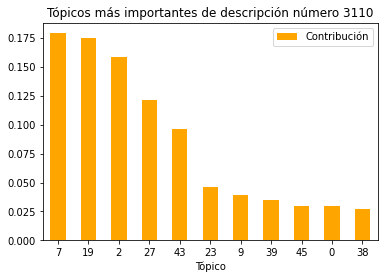

In [371]:
# Graficación de distribución de tópicos
distribucion_topicos = pd.DataFrame({'Tópico': distribucion_indices,
                                     'Contribución': contribucion_distribucion})
distribucion_topicos.sort_values('Contribución', 
                                 ascending= False, inplace= True)
ax = distribucion_topicos.plot.bar(y= 'Contribución', x= 'Tópico', 
                                   rot= 0, color= "orange",
                                  title = 'Tópicos más importantes'
                                   ' de descripción número ' + str(indice_topico))

In [372]:
# Impresión de distribución de tópicos
print(texto_topico['Descripción'], '\n')
for ind, topico in distribucion_topicos.iterrows():
    print("*** Tópico: " + str(int(topico.Tópico)) + " ***")
    palabras = [palabra[0] for palabra in lda_gensim.show_topic(
        topicid=int(topico.Tópico))]
    palabras = ', '.join(palabras)
    print(palabras, "\n")

Pequeño museo que posee un compendio de 187 piezas de la cultura tlatilca, el cual data de los años 1200 Y 750 a.C.
Con esta exhibición el público visitante conoce la cosmovisión de los tlatilcas, sus relaciones de comercio con otras culturas, así como su influencia directa con los olmecas. La colección en exposición destaca las bellas piezas de barro que representan a mujeres de caderas exageradas, símbolo de fecundidad, así como vasijas y restos de fósiles localizados en la zona. 

*** Tópico: 7 ***
museo, pieza,  , colección, histórico, exhibir, nacional, historia, historio, patrimonio 

*** Tópico: 19 ***
 , año, edificio, siglo, nombre, casa, ciudad, antiguo, época, inmueble 

*** Tópico: 2 ***
 , siglo, importante, ciudad, periodo, vida, zona, museo, formar, prehispánico 

*** Tópico: 27 ***
visitante, persona, asistencia, año,  , casa, tipo, general, público, cultural 

*** Tópico: 43 ***
arqueológico, sitio,  , principal, piedra, templo, conjunto, plaza, arquitectónico, estilo 